# 2d. Cleaning Priority Ranking

**Purpose:** combine `2b` (fouling rate, current Q drop) and `2c` (Q-CIT
sensitivity) into one ranked table: which HX is most worth cleaning, and how
much CIT it should recover.

**Combining rule:**
- Only HX currently `active` (per `2b`'s `currently_active` flag) are ranked —
  a unit that is off/substituted has no live fouling status to act on.
- Sensitivity sign matters. A HX with a **positive** Q-CIT sensitivity behaves
  as physically expected (more duty -> more CIT): expected gain =
  `current Q shortfall x sensitivity`, taken as-is.
- A HX with a **negative** sensitivity is a terminal-position pinch effect
  (see `2c` section 1.1), not a real fouling-to-CIT link for that unit through
  this particular regression. Its expected CIT gain is **not estimated by this
  method** — it's flagged separately rather than reported as a (nonsensical)
  negative gain, since cleaning can never be expected to *lower* CIT.
- Priority score = normalised fouling rate x normalised sensitivity magnitude
  (only for positive-sensitivity HX) -- the two must both be present for a
  cleaning event to be worth prioritising highly.

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from cpht_config import CPHT_1_HX, CPHT_2_HX

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

fouling = pd.read_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv')
sens = pd.read_csv(DATA_DIR + r'\Q_CIT_Sensitivity.csv')

ranking = fouling.merge(sens[['HX', 'CIT_sensitivity_degC_per_Qnorm', 'Q_CIT_corr']], on='HX', how='left')
print(f'Merged ranking table: {ranking.shape}')
ranking

Merged ranking table: (16, 12)


,HX,group,n_campaigns,median_Q_slope,median_pct_drop_per_30d,median_R2,mean_Q_norm,Q_drop_pct,days_in_campaign,currently_active,CIT_sensitivity_degC_per_Qnorm,Q_CIT_corr
0,E113A,CPHT-2,11,-0.027156,-5.305005,0.390065,19.162626,49.6,158,True,0.056,0.2191
1,E112C,CPHT-2,4,-0.021875,-5.344032,0.264852,30.075223,11.0,156,False,-0.150,-0.7008
2,E107AB,CPHT-2,17,-0.013109,-6.524020,0.179236,4.218858,19.1,110,True,-0.553,-0.2176
3,E106AB,CPHT-2,3,-0.004265,-1.051690,0.282998,8.609504,59.8,1838,True,0.280,0.1548
4,E109AB,CPHT-2,13,-0.004138,-3.431461,0.100069,4.446990,32.8,597,True,-1.818,-0.3892
5,E112AB,CPHT-2,10,-0.003273,-1.079193,0.083405,8.358868,-10.7,141,True,0.001,0.0003
6,E101AB,CPHT-1,1,-0.001916,-0.531998,0.605776,8.854739,40.0,2007,True,1.231,0.2885
7,E111,CPHT-2,10,-0.001727,-1.073878,0.012840,3.703453,19.0,566,True,-1.411,-0.3045
8,E104,CPHT-2,2,-0.001646,-0.361308,0.550936,7.751731,50.4,747,True,0.467,0.0929
9,E101CD,CPHT-1,1,-0.001338,-0.467079,0.479187,7.245102,43.5,2007,True,1.789,0.3327


---
## 1.5 Hot-End Coking / Asphaltene Precipitation Risk

**Physical basis:** the last HX before the crude column/furnace run at crude
outlet temperatures approaching or exceeding 250°C. At this range, fouling
stops being simple particulate/scale deposition and starts including
**chemical reaction fouling** — coking and asphaltene precipitation — which
tends to be faster, more temperature-sensitive (roughly Arrhenius: rate
accelerates with T), and harder to reverse than low-temperature fouling. Most
refineries schedule their hottest preheat-train HX for the most frequent
cleaning/swap specifically because of this, independent of how much CIT a
clean happens to recover.

**Why this matters for this ranking specifically:** the CIT-sensitivity
regression in `2c` gave a *negative* slope for the hottest units in the train
— `E113A`, `E112C` (mean crude-out 249.5°C, >250°C on 47.7% of days),
`E109AB` and `E112AB` (mean ~226°C) — because they sit at the *end* of a
series chain (pinch effect, see `2c` section 1.1), not because cleaning them
doesn't matter. Section 2 of this notebook therefore excludes them from the
CIT-gain ranking entirely. **That's the wrong answer for these specific
units** — they are exactly the ones a refinery engineer would flag first on
physical grounds, and `E113A` already shows the **fastest fouling rate of all
16 HX** in this dataset (-10.3%/30d, see `2b`). This section builds a
separate, temperature-risk-weighted score for them instead of a CIT-gain
estimate, and section 4 merges both into one final action list.

In [2]:
FILEPATH = r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_with_crude.csv'
df_temp = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)

from cpht_config import HX_CONFIG

HOT_END_THRESH_C = 220.0   # degC -- mean crude-out above this = coking/asphaltene risk zone

temp_rows = []
for hx, cfg in HX_CONFIG.items():
    tag = cfg['cold_out']
    if tag not in df_temp.columns:
        continue
    s = df_temp[tag]
    temp_rows.append({
        'HX': hx,
        'mean_cold_out_C': round(s.mean(), 1),
        'max_cold_out_C': round(s.max(), 1),
        'frac_gt_250C_pct': round((s > 250).mean() * 100, 1),
        'hot_end': s.mean() > HOT_END_THRESH_C,
    })

temp_df = pd.DataFrame(temp_rows).sort_values('mean_cold_out_C', ascending=False).reset_index(drop=True)
print(f'Hot-end HX (mean crude-out > {HOT_END_THRESH_C:.0f} degC): '
      f'{temp_df["hot_end"].sum()} / {len(temp_df)}')
temp_df

Hot-end HX (mean crude-out > 220 degC): 5 / 16


,HX,mean_cold_out_C,max_cold_out_C,frac_gt_250C_pct,hot_end
0,E113A,248.1,264.4,35.2,True
1,E112C,248.1,264.4,35.2,True
2,E105AB,230.6,259.6,2.4,True
3,E112AB,224.8,255.0,0.8,True
4,E109AB,222.5,250.1,0.1,True
5,E108AB,189.2,227.7,0.0,False
6,E111,169.4,197.2,0.0,False
7,E104,168.7,188.6,0.0,False
8,E107AB,168.1,300.0,0.6,False
9,E110ABC,144.7,188.9,0.0,False


### 1.6 Coking-Risk Score

`coking_risk = normalize(fouling_rate_abs) x normalize(mean_cold_out_temp)` —
same product-of-two-normalised-signals structure as the main priority score in
section 3, but temperature substitutes for CIT-sensitivity as the second
factor. Computed for every currently-active HX (not just the hot-end ones) so
it's directly comparable, but it will naturally be low for cool upstream HX
regardless of their fouling rate.

In [3]:
def minmax_local(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0, index=s.index)

coking = ranking.merge(temp_df[['HX', 'mean_cold_out_C', 'max_cold_out_C', 'frac_gt_250C_pct', 'hot_end']],
                        on='HX', how='left')
coking = coking[coking['currently_active']].copy()
coking['fouling_rate_abs'] = coking['median_pct_drop_per_30d'].clip(upper=0).abs()
coking['coking_risk_score'] = minmax_local(coking['fouling_rate_abs']) * minmax_local(coking['mean_cold_out_C'])

coking_ranked = coking.sort_values('coking_risk_score', ascending=False).reset_index(drop=True)
coking_ranked[['HX', 'group', 'mean_cold_out_C', 'frac_gt_250C_pct', 'median_pct_drop_per_30d',
               'coking_risk_score', 'hot_end']].round(4)

,HX,group,mean_cold_out_C,frac_gt_250C_pct,median_pct_drop_per_30d,coking_risk_score,hot_end
0,E113A,CPHT-2,248.1,35.2,-5.3050,0.8131,True
1,E107AB,CPHT-2,168.1,0.6,-6.5240,0.4898,False
2,E109AB,CPHT-2,222.5,0.1,-3.4315,0.4401,True
3,E112AB,CPHT-2,224.8,0.8,-1.0792,0.1408,True
4,E111,CPHT-2,169.4,0.0,-1.0739,0.0820,False
5,E106AB,CPHT-2,136.0,0.0,-1.0517,0.0460,False
6,E104,CPHT-2,168.7,0.0,-0.3613,0.0273,False
7,E102,CPHT-1,93.4,0.0,-0.2211,0.0005,False
8,E101CD,CPHT-1,92.0,0.0,-0.4671,0.0003,False
9,E101AB,CPHT-1,91.3,0.0,-0.5320,0.0000,False


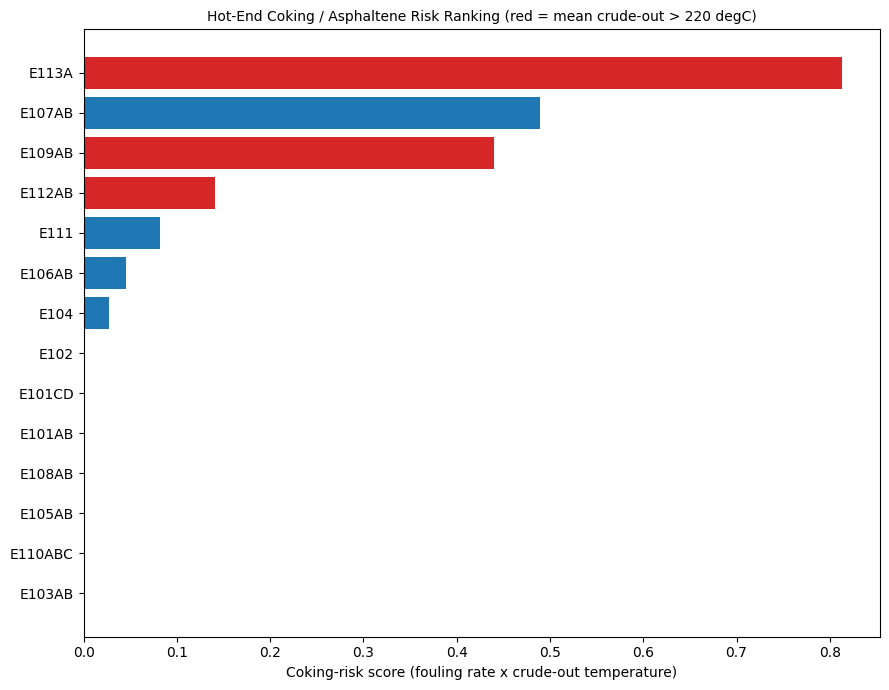

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d62728' if h else '#1f77b4' for h in coking_ranked['hot_end']]
ax.barh(coking_ranked['HX'], coking_ranked['coking_risk_score'], color=colors)
ax.set_xlabel('Coking-risk score (fouling rate x crude-out temperature)')
ax.set_title('Hot-End Coking / Asphaltene Risk Ranking (red = mean crude-out > 220 degC)', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2d_coking_risk_ranking.png'), bbox_inches='tight')
plt.show()

---
## 1.7 Residue (Bottom Stream) Chain — Crude-Batch-Driven Fouling Risk

**Physical basis:** `E113A`/`E112C` → `E112AB` → `E108AB` → `E110ABC` all share the
**same residue (C101 bottoms) stream in series** — it gives up heat to four
different crude branches in sequence, cooling and (because petroleum
viscosity rises sharply as temperature falls) becoming **more viscous** at
each successive stage. This is a different fouling mechanism from the
temperature/coking risk in section 1.5: viscous-film deposition can be
significant even in the *cooler*, downstream members of this chain
(`E108AB`, `E110ABC`) precisely because the residue is still heavy but no
longer hot enough to stay mobile. And because crude feed composition varies
batch to batch, a run of heavier crude (lower API, higher asphaltenes/MCRT)
produces heavier residue, which should raise fouling risk across the *whole*
chain simultaneously, not just one HX.

**What the data can and can't say:** joining each HX's per-run fouling rate
(`Fouling_Rate_By_Run.csv`, from `02_feature_engineering.ipynb`) to the average
crude assay properties during that run's window gives a **directly
rate-based** test of the crude-quality hypothesis (avoiding the
calendar-time confound that affected the raw `U_relative`-level correlation
in `2_correlation.ipynb`). But these HX have very few online-clean events
(3-6 runs each over ~2.3 years), so **none of the per-HX correlations below
are statistically significant** (p > 0.15 throughout) — shown for engineering
awareness, not as a scored ranking input. Re-check once more cleaning cycles
have accumulated.

In [5]:
FR_PATH = r'C:\Desktop\Bangchak Internship 2026\Data\Fouling_Rate_By_Run.csv'
fouling_rate_by_run = pd.read_csv(FR_PATH, parse_dates=['Run_start'])

from scipy import stats as scipy_stats

RESIDUE_CHAIN_HX = ['E113A', 'E112C', 'E112AB', 'E108AB', 'E110ABC']
# Position 1 = hottest / first to see the residue (highest coking risk),
# position 4 = coolest / last (highest relative-viscosity risk instead)
RESIDUE_CHAIN_POSITION = {'E113A': 1, 'E112C': 1, 'E112AB': 2, 'E108AB': 3, 'E110ABC': 4}

CRUDE_COLS_RISK = ['API', 'SG_15_6C', 'Visc_50C_cSt', 'Visc_100C_cSt', 'MCRT_pct', 'Asphaltenes_pct']

rate_crude_rows = []
for _, run in fouling_rate_by_run.iterrows():
    hx = run['HX']
    if hx not in RESIDUE_CHAIN_HX:
        continue
    start = run['Run_start']
    end = start + pd.Timedelta(days=int(run['Duration_days']))
    window_mean = df_temp.loc[start:end, CRUDE_COLS_RISK].mean()
    rec = {'HX': hx, 'Run': run['Run'], 'dUrel_per_month': run['dUrel_per_month'], 'N_runs_pts': run['N_regression_pts']}
    rec.update(window_mean.to_dict())
    rate_crude_rows.append(rec)

rate_crude_df = pd.DataFrame(rate_crude_rows)

print('Fouling RATE vs crude property, per residue-chain HX (exploratory -- see caveat above):')
exploratory_rows = []
for hx in RESIDUE_CHAIN_HX:
    sub = rate_crude_df[rate_crude_df['HX'] == hx]
    n_runs = len(sub)
    if n_runs < 3:
        print(f'  {hx}: only {n_runs} run(s) -- not enough to correlate')
        continue
    for cp in CRUDE_COLS_RISK:
        if sub[cp].notna().sum() >= 3:
            r, p = scipy_stats.spearmanr(sub['dUrel_per_month'], sub[cp])
            exploratory_rows.append({'HX': hx, 'n_runs': n_runs, 'crude_property': cp,
                                      'rate_vs_property_r': round(r, 3), 'p_value': round(p, 3)})

exploratory_df = pd.DataFrame(exploratory_rows)
print(f'  (all {len(exploratory_df)} correlations shown; none reach p<0.05 with this few runs)')
exploratory_df

Fouling RATE vs crude property, per residue-chain HX (exploratory -- see caveat above):
  (all 30 correlations shown; none reach p<0.05 with this few runs)


,HX,n_runs,crude_property,rate_vs_property_r,p_value
0,E113A,18,API,NaN,NaN
1,E113A,18,SG_15_6C,NaN,NaN
2,E113A,18,Visc_50C_cSt,NaN,NaN
3,E113A,18,Visc_100C_cSt,NaN,NaN
4,E113A,18,MCRT_pct,NaN,NaN
5,E113A,18,Asphaltenes_pct,NaN,NaN
6,E112C,14,API,NaN,NaN
7,E112C,14,SG_15_6C,NaN,NaN
8,E112C,14,Visc_50C_cSt,NaN,NaN
9,E112C,14,Visc_100C_cSt,NaN,NaN


### 1.8 Residue-Chain Structural Risk Score

Since the crude-property correlation isn't statistically usable yet, the
scored factor here is **structural**: chain membership + position (proxy for
cumulative residue exposure) combined with each HX's own measured fouling
rate (which *is* reliable, from `2b`/`02_feature_engineering`). This doesn't
assume a crude-quality effect size that the data can't support -- it captures
"this HX sits in the shared bottom-stream chain and is fouling at rate X",
which is enough to prioritise within the chain even before the crude-quality
question is resolved statistically.

In [6]:
residue_risk = ranking[ranking['HX'].isin(RESIDUE_CHAIN_HX) & ranking['currently_active']].copy()
residue_risk['chain_position'] = residue_risk['HX'].map(RESIDUE_CHAIN_POSITION)
residue_risk['fouling_rate_abs'] = residue_risk['median_pct_drop_per_30d'].clip(upper=0).abs()

# Mild upweight for later chain positions (cumulative exposure to an
# increasingly viscous, still-heavy stream), not a substitute for temperature
residue_risk['exposure_weight'] = 1 + 0.15 * (residue_risk['chain_position'] - 1)
residue_risk['residue_chain_risk_score'] = (
    minmax_local(residue_risk['fouling_rate_abs']) * residue_risk['exposure_weight']
)
residue_risk['residue_chain_risk_score'] = minmax_local(residue_risk['residue_chain_risk_score'])

residue_risk = residue_risk.sort_values('residue_chain_risk_score', ascending=False).reset_index(drop=True)
residue_risk[['HX', 'chain_position', 'median_pct_drop_per_30d', 'exposure_weight', 'residue_chain_risk_score']].round(4)

,HX,chain_position,median_pct_drop_per_30d,exposure_weight,residue_chain_risk_score
0,E113A,1,-5.3050,1.00,1.0000
1,E112AB,2,-1.0792,1.15,0.2339
2,E108AB,3,2.0400,1.30,0.0000
3,E110ABC,4,0.6180,1.45,0.0000


---
## 1. Expected CIT Gain if Cleaned

`Q_shortfall = baseline_Q_norm - current_Q_norm` (from the current campaign,
`2b` section 5) — how much duty has been lost to fouling so far.
`expected_CIT_gain = Q_shortfall x CIT_sensitivity` for positive-sensitivity
HX only.

In [7]:
ranking['Q_shortfall'] = ranking['mean_Q_norm'] * ranking['Q_drop_pct'] / 100
# mean_Q_norm is a campaign-average proxy for baseline scale; Q_drop_pct is already
# baseline-relative (see 2b section 5), so this recovers an absolute Q_norm shortfall.

positive_sens = ranking['CIT_sensitivity_degC_per_Qnorm'] > 0
ranking['expected_CIT_gain_C'] = np.where(
    positive_sens,
    (ranking['Q_shortfall'] * ranking['CIT_sensitivity_degC_per_Qnorm']).clip(lower=0),
    np.nan
)
ranking['gain_estimable'] = positive_sens

print(f'HX with an estimable (positive-sensitivity) CIT gain: {positive_sens.sum()} / {len(ranking)}')
ranking[['HX', 'group', 'currently_active', 'Q_drop_pct', 'CIT_sensitivity_degC_per_Qnorm',
         'expected_CIT_gain_C', 'gain_estimable']].sort_values('expected_CIT_gain_C', ascending=False)

HX with an estimable (positive-sensitivity) CIT gain: 12 / 16


,HX,group,currently_active,Q_drop_pct,CIT_sensitivity_degC_per_Qnorm,expected_CIT_gain_C,gain_estimable
15,E101EF,CPHT-1,False,99.3,1.905,11.846739,True
10,E102,CPHT-1,True,49.9,6.872,9.177835,True
9,E101CD,CPHT-1,True,43.5,1.789,5.638247,True
6,E101AB,CPHT-1,True,40.0,1.231,4.360074,True
13,E110ABC,CPHT-2,True,65.2,0.312,2.243221,True
8,E104,CPHT-2,True,50.4,0.467,1.824509,True
3,E106AB,CPHT-2,True,59.8,0.280,1.441575,True
14,E103AB,CPHT-2,True,69.9,0.118,0.997074,True
0,E113A,CPHT-2,True,49.6,0.056,0.532261,True
11,E108AB,CPHT-2,True,31.7,0.250,0.239434,True


In [8]:
# --- Direct CIT-gain override for E113A / E112C (unit-corrected) ---
# E113A/E112C are the terminal HX right before the furnace; CIT_TAG (1TI116.pv) IS
# their own cold_out, so their fouling-driven duty loss maps one-to-one to CIT loss
# (no pinch-effect confound -- their Q-CIT correlation is negative, see 2c).
#
# BUG FIX: current_deviation in Time_To_Clean_Prediction.csv is a Q-DUTY deviation
# (kW) -- 3a predicts Q, not cold_out temperature. Using it directly as degC gave a
# physically impossible ~1673 "degC". Convert with the SAME heat balance that defines
# Q  (Q = rho * flow * Cp * dT):   dT_degC = dQ_kW * 3600 / (rho * flow * Cp).
TTC_PATH = r'C:\Desktop\Bangchak Internship 2026\Data\Time_To_Clean_Prediction.csv'
try:
    from cpht_config import PROCESS_WITH_CRUDE_CSV as _PWC, TOTAL_CHARGE_TAG as _CHG
    from cpht_features import RHO_CRUDE as _RHO, CP_CRUDE as _CP
    _charge = pd.read_csv(_PWC, index_col=0)[_CHG].mean()          # total crude charge, m3/h
    _kw_to_degC = 3600.0 / (_RHO * _charge * _CP)                  # kW -> degC for E113A/E112C
    _ttc = pd.read_csv(TTC_PATH).set_index('HX')['current_deviation']
    for _hx in ['E113A', 'E112C']:
        if _hx in ranking['HX'].values and _hx in _ttc.index:
            gain = max(float(_ttc[_hx]) * _kw_to_degC, 0.0)
            ranking.loc[ranking['HX'] == _hx, 'expected_CIT_gain_C'] = round(gain, 3)
            ranking.loc[ranking['HX'] == _hx, 'gain_estimable'] = True
    print(f'Direct CIT-gain override for E113A/E112C '
          f'(dQ[kW] x {_kw_to_degC:.5f} -> degC, charge={_charge:.0f} m3/h):')
    print(ranking.loc[ranking['HX'].isin(['E113A', 'E112C']),
                       ['HX', 'expected_CIT_gain_C', 'gain_estimable']])
except FileNotFoundError:
    print('Time_To_Clean_Prediction.csv not found -- run 3b first; E113A/E112C gain stays regression-based (NaN).')

Direct CIT-gain override for E113A/E112C (dQ[kW] x 0.00369 -> degC, charge=521 m3/h):
      HX  expected_CIT_gain_C  gain_estimable
0  E113A                9.197            True
1  E112C                  NaN           False


---
## 2. Combined Priority Score

Only currently-active HX with an estimable (positive-sensitivity) gain are
scored. `priority = normalize(fouling_rate_abs) x normalize(CIT_sensitivity)`
— equal-weight product means an HX needs to score reasonably on *both* axes to
rank highly (a fast-fouling but low-sensitivity HX, or a high-sensitivity but
barely-fouling HX, both stay low priority).

In [9]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0, index=s.index)

scoreable = ranking[ranking['currently_active'] & ranking['gain_estimable']].copy()

scoreable['fouling_rate_abs'] = scoreable['median_pct_drop_per_30d'].clip(upper=0).abs()
scoreable['priority_score'] = (
    minmax(scoreable['fouling_rate_abs']) * minmax(scoreable['CIT_sensitivity_degC_per_Qnorm'])
)

priority = scoreable.sort_values('priority_score', ascending=False).reset_index(drop=True)
priority[['HX', 'group', 'median_pct_drop_per_30d', 'CIT_sensitivity_degC_per_Qnorm',
          'expected_CIT_gain_C', 'priority_score']].round(4)

,HX,group,median_pct_drop_per_30d,CIT_sensitivity_degC_per_Qnorm,expected_CIT_gain_C,priority_score
0,E102,CPHT-1,-0.2211,6.872,9.1778,0.0417
1,E101CD,CPHT-1,-0.4671,1.789,5.6382,0.0229
2,E101AB,CPHT-1,-0.5320,1.231,4.3601,0.0180
3,E106AB,CPHT-2,-1.0517,0.280,1.4416,0.0080
4,E113A,CPHT-2,-5.3050,0.056,9.1970,0.0080
5,E104,CPHT-2,-0.3613,0.467,1.8245,0.0046
6,E112AB,CPHT-2,-1.0792,0.001,0.0000,0.0000
7,E108AB,CPHT-2,2.0400,0.250,0.2394,0.0000
8,E105AB,CPHT-2,0.3855,1.418,0.0000,0.0000
9,E110ABC,CPHT-2,0.6180,0.312,2.2432,0.0000


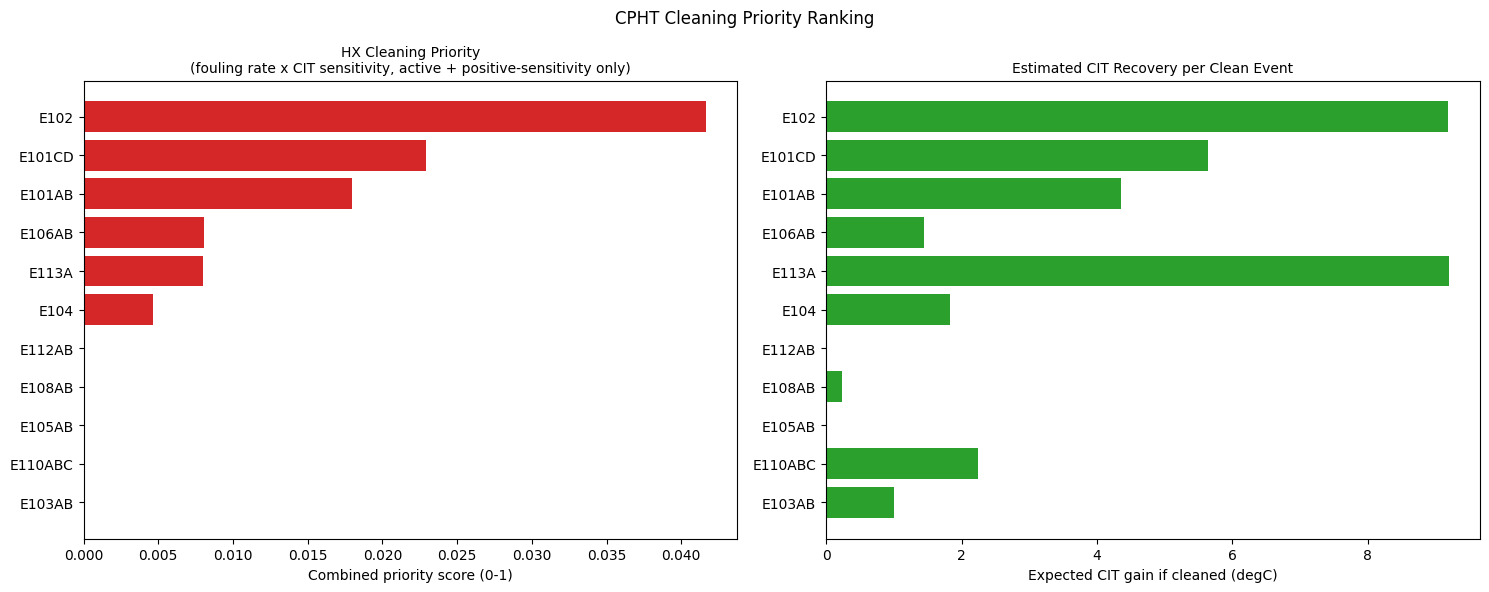

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(priority['HX'], priority['priority_score'], color='tab:red')
axes[0].set_xlabel('Combined priority score (0-1)')
axes[0].set_title('HX Cleaning Priority\n(fouling rate x CIT sensitivity, active + positive-sensitivity only)',
                   fontsize=10)
axes[0].invert_yaxis()

axes[1].barh(priority['HX'], priority['expected_CIT_gain_C'], color='tab:green')
axes[1].set_xlabel('Expected CIT gain if cleaned (degC)')
axes[1].set_title('Estimated CIT Recovery per Clean Event', fontsize=10)
axes[1].invert_yaxis()

plt.suptitle('CPHT Cleaning Priority Ranking', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2d_cleaning_priority.png'), bbox_inches='tight')
plt.show()

---
## 3. Terminal-Position HX -- Ranked by Coking Risk, Not CIT Gain

These HX show real, non-confounded fouling (from `2b`) but their Q-CIT
regression slope is negative for the pinch/terminal-position reason explained
in `2c`, so this method can't size their CIT benefit directly -- they are NOT
just set aside, though: section 1.5/1.6 above gives them a temperature-risk
score instead, since several of them (`E113A`, `E112C`, `E112AB`, `E109AB`)
are exactly the hot-end, coking/asphaltene-prone units a refinery engineer
would prioritise on physical grounds regardless of the CIT-gain number.
`E113A` in particular has the **fastest fouling rate of all 16 HX** in this
dataset -- it belongs near the top of the action list, not off to the side.

In [11]:
flagged = ranking[ranking['currently_active'] & ~ranking['gain_estimable']].copy()
flagged = flagged.merge(
    coking_ranked[['HX', 'mean_cold_out_C', 'frac_gt_250C_pct', 'coking_risk_score', 'hot_end']],
    on='HX', how='left'
).sort_values('coking_risk_score', ascending=False)
flagged[['HX', 'group', 'mean_cold_out_C', 'frac_gt_250C_pct', 'median_pct_drop_per_30d',
         'CIT_sensitivity_degC_per_Qnorm', 'coking_risk_score']].round(4)

,HX,group,mean_cold_out_C,frac_gt_250C_pct,median_pct_drop_per_30d,CIT_sensitivity_degC_per_Qnorm,coking_risk_score
0,E107AB,CPHT-2,168.1,0.6,-6.5240,-0.553,0.4898
1,E109AB,CPHT-2,222.5,0.1,-3.4315,-1.818,0.4401
2,E111,CPHT-2,169.4,0.0,-1.0739,-1.411,0.0820


---
## 4. Not Currently Active -- No Live Status

Off/substituted at present (`2a`/`2b`) -- no current fouling reading to rank.

In [12]:
inactive = ranking[~ranking['currently_active']]
inactive[['HX', 'group', 'campaign_start' if 'campaign_start' in ranking.columns else 'HX']] if len(inactive) else inactive
print(f'{len(inactive)} HX currently not active: {inactive["HX"].tolist()}')

2 HX currently not active: ['E112C', 'E101EF']


---
## 4. Comprehensive Engineering Priority Score (Risk-Based: Probability x Consequence / Effort)

Sections 1-3 each answer a narrower question (CIT benefit, temperature-driven
coking risk, residue-chain structural risk). This section combines them with
three more engineering dimensions a refinery would normally weigh before
scheduling a clean, using a classic risk-based-inspection structure:

```
Engineering Priority = (Probability_score x Consequence_score) / Effort_penalty
```

- **Probability_score** -- how fast is it actually fouling, and how much do
  we trust that number: fouling rate x data confidence (R-squared of the
  latest run's regression) x a trajectory multiplier (is the rate worsening
  run-over-run, a leading indicator of an emerging problem, e.g. a heavier
  crude slate).
- **Consequence_score** -- what happens if it's left fouled: CIT/energy value
  (from section 2) plus a safety/mechanical flag for hot-end (coking,
  section 1.5-1.6) and residue-chain (under-deposit corrosion risk on a
  hot residue-carrying HX, section 1.7-1.8) membership. Default weighting
  here is **safety-consequence 2x energy-value** (`SAFETY_WEIGHT` /
  `ENERGY_WEIGHT` below) -- a standard process-safety-first convention absent
  plant-specific guidance; change these constants if actual priority differs.
- **Effort_penalty** -- feasibility, from demonstrated cleaning history
  (`Fouling_Rate_By_Run.csv` run counts) plus known spare-shell pairs
  (`E113A<->E112C`, `E101EF<->E101G`): `SWAP_CAPABLE` (documented parallel
  spare, lowest effort) < `ONLINE_CLEAN_DEMONSTRATED` (at least one online
  clean event seen in this dataset, no dedicated spare) < `TAM_ONLY` (never
  reset outside the single plant-wide TAM in this data -- infeasible to
  schedule independently).

**Explicitly not included** (no data provided): actual cleaning cost/duration
per method, next TAM date, tube inspection/corrosion survey history. The
`safety_flag` below is a **qualitative placeholder** (hot-end or
residue-chain membership) standing in for real corrosion/RBI data --
replace it with actual inspection findings when available.

In [13]:
# --- Effort tier (feasibility) — SINGLE SOURCE: bypass_config.py, parsed from the
# real plant file (Data/list bypass Cleaning Heat Exchanger.xlsx). 2026-07-12 fix:
# this used to be a hand-written guess that directly contradicted the plant file
# (e.g. E103AB/E106AB/E107AB/E109AB were marked "online-clean demonstrated" despite
# having NO bypass per the sheet; E101AB/E105AB were marked TAM-only despite HAVING
# one). Swap-capable spare pairs (E113A<->E112C) still come from cpht_config.
import sys as _sys; _sys.path.append('.')
from bypass_config import BYPASS_CONFIG
from cpht_config import PARALLEL_SHELL_GROUPS
_SWAP = {a for pair in PARALLEL_SHELL_GROUPS for a in pair} | {b for pair in PARALLEL_SHELL_GROUPS for b in (pair[1],)}
_SWAP = {a for pair in PARALLEL_SHELL_GROUPS for a in pair}
EFFORT_PENALTY = {'SWAP_CAPABLE': 1.0, 'ONLINE_FULL': 2.5, 'ONLINE_PARTIAL': 4.0, 'TAM_ONLY': 6.0}

def classify_effort(hx):
    if hx in _SWAP:
        return 'SWAP_CAPABLE'
    mode = BYPASS_CONFIG.get(hx, {}).get('online_mode', 'none')
    return {'full': 'ONLINE_FULL', 'partial': 'ONLINE_PARTIAL', 'none': 'TAM_ONLY'}[mode]

eng = ranking[ranking['currently_active']].copy()
eng['fouling_rate_abs'] = eng['median_pct_drop_per_30d'].clip(upper=0).abs()
eng['effort_tier'] = eng['HX'].map(classify_effort)
eng['duty_fraction'] = eng['HX'].map(lambda h: BYPASS_CONFIG.get(h, {}).get('duty_fraction', 0.0 if classify_effort(h)=='TAM_ONLY' else 1.0))
eng['effort_penalty'] = eng['effort_tier'].map(EFFORT_PENALTY)

print('Effort tier distribution (from real bypass file, not a hardcoded guess):')
print(eng['effort_tier'].value_counts())
eng[['HX', 'effort_tier', 'duty_fraction', 'effort_penalty']]

Effort tier distribution (from real bypass file, not a hardcoded guess):
effort_tier
ONLINE_FULL       8
TAM_ONLY          4
SWAP_CAPABLE      1
ONLINE_PARTIAL    1
Name: count, dtype: int64


,HX,effort_tier,duty_fraction,effort_penalty
0,E113A,SWAP_CAPABLE,1.0,1.0
2,E107AB,TAM_ONLY,0.0,6.0
3,E106AB,TAM_ONLY,0.0,6.0
4,E109AB,TAM_ONLY,0.0,6.0
5,E112AB,ONLINE_FULL,1.0,2.5
6,E101AB,ONLINE_FULL,1.0,2.5
7,E111,ONLINE_FULL,1.0,2.5
8,E104,ONLINE_FULL,1.0,2.5
9,E101CD,ONLINE_PARTIAL,0.5,4.0
10,E102,ONLINE_FULL,1.0,2.5


In [14]:
# --- Trajectory (run-over-run worsening) and data confidence (R^2), from per-run history ---
traj_rows = []
for hx, grp in fouling_rate_by_run.sort_values(['HX', 'Run']).groupby('HX'):
    grp = grp.dropna(subset=['dUrel_per_month'])
    if len(grp) == 0:
        continue
    latest = grp.iloc[-1]
    trajectory_delta = np.nan
    if len(grp) >= 2:
        trajectory_delta = latest['dUrel_per_month'] - grp.iloc[-2]['dUrel_per_month']
    traj_rows.append({'HX': hx, 'latest_R2': latest['R2'], 'trajectory_delta': trajectory_delta})

traj_df = pd.DataFrame(traj_rows)
traj_df['worsening'] = traj_df['trajectory_delta'] < 0
# R^2 floor at 0.3 so one noisy run doesn't zero out an otherwise-real fouling signal
traj_df['confidence_weight'] = traj_df['latest_R2'].clip(lower=0.3, upper=1.0)
# Accelerating fouling (more negative than the previous run) = 25% urgency boost
traj_df['trajectory_multiplier'] = np.where(traj_df['worsening'], 1.25, 1.0)

eng = eng.merge(
    traj_df[['HX', 'latest_R2', 'trajectory_delta', 'worsening', 'confidence_weight', 'trajectory_multiplier']],
    on='HX', how='left'
)
print(f"HX with a worsening trend vs their own previous run: {eng['worsening'].sum()} / {eng['worsening'].notna().sum()}")
eng[['HX', 'latest_R2', 'trajectory_delta', 'worsening', 'confidence_weight']].round(4)

HX with a worsening trend vs their own previous run: 5 / 14


,HX,latest_R2,trajectory_delta,worsening,confidence_weight
0,E113A,0.334,0.0362,False,0.334
1,E107AB,0.102,0.0033,False,0.300
2,E106AB,0.014,0.0328,False,0.300
3,E109AB,0.109,0.1151,False,0.300
4,E112AB,-0.348,0.1244,False,0.300
5,E101AB,0.852,-0.0043,True,0.852
6,E111,0.716,0.0085,False,0.716
7,E104,0.896,0.0556,False,0.896
8,E101CD,0.763,0.0054,False,0.763
9,E102,0.528,0.0015,False,0.528


### 4.1 Consequence & Final Combined Score

**Consequence = energy value + 2x safety.** The energy value is the *measured* Q-duty
shortfall (`Q_shortfall`, physical, reliable); the CIT-model-derived `expected_CIT_gain_C`
is kept only as a **down-weighted (0.25) secondary** because the CIT point model does not
beat a persistence baseline out-of-sample (see `6a`). All components use **rank-percentile
normalisation** (not min-max) so a single fouling-rate outlier no longer collapses every
other HX to ~0 -- the score now reflects relative *order*, with raw magnitudes still shown.

`engineering_priority_score = rank_norm( Probability x Consequence / Effort )`.

In [15]:
SAFETY_WEIGHT = 2.0    # default: safety/mechanical consequence weighted 2x pure energy value
ENERGY_WEIGHT = 1.0

eng = eng.merge(coking_ranked[['HX', 'mean_cold_out_C', 'hot_end']], on='HX', how='left')
eng['residue_chain_member'] = eng['HX'].isin(RESIDUE_CHAIN_HX)
eng['safety_flag'] = eng['hot_end'].fillna(False) | eng['residue_chain_member']

# --- D6 fix: rank-percentile normaliser (robust) ---------------------------------
# min-max collapsed every HX except the single fouling-rate outlier (E113A ~10x the
# median) to ~0, so the composite read E113A=1.00 and everyone else ~0. rank_norm
# spreads the set uniformly on 0..1 by ORDER, which is what a priority *ranking*
# actually needs; raw magnitudes (fouling_rate_abs, Q_drop_pct) are still shown for context.
def rank_norm(s):
    return s.rank(pct=True, method='average')

# --- D6 fix: consequence uses MEASURED physical duty loss as primary --------------
# The energy value of cleaning was previously driven by expected_CIT_gain_C, which is
# derived from the CIT point model -- and that model does NOT beat a persistence baseline
# out-of-sample (see 6a). So we make the *measured* Q-duty shortfall (Q_shortfall, from
# section 1) the primary energy signal, and keep the CIT-model gain only as a
# down-weighted (0.25) secondary/tie-breaker with its documented CPHT-1 indirect discount.
if 'Q_shortfall' not in eng.columns:
    eng = eng.merge(ranking[['HX', 'Q_shortfall']], on='HX', how='left')
eng['energy_phys_norm'] = rank_norm(eng['Q_shortfall'].fillna(0).clip(lower=0))

CPHT1_INDIRECT_DISCOUNT = 0.5   # CPHT-1 affects CIT only indirectly via desalter (documented, tunable)
eng['expected_CIT_gain_C_adj'] = eng['expected_CIT_gain_C']
is_cpht1 = eng['HX'].isin(CPHT_1_HX)
eng.loc[is_cpht1, 'expected_CIT_gain_C_adj'] = eng.loc[is_cpht1, 'expected_CIT_gain_C'] * CPHT1_INDIRECT_DISCOUNT
eng['energy_cit_norm'] = rank_norm(eng['expected_CIT_gain_C_adj'].fillna(0).clip(lower=0))

CIT_SECONDARY_WEIGHT = 0.25   # CIT-model gain is a weak (non-validated) signal -> low weight vs measured Q
eng['energy_value_norm'] = (eng['energy_phys_norm'] + CIT_SECONDARY_WEIGHT * eng['energy_cit_norm']) \
                           / (1 + CIT_SECONDARY_WEIGHT)

eng['safety_value_norm'] = eng['safety_flag'].astype(float)
eng['consequence_score'] = (ENERGY_WEIGHT * eng['energy_value_norm']
                            + SAFETY_WEIGHT * eng['safety_value_norm']) / (ENERGY_WEIGHT + SAFETY_WEIGHT)

# probability = how likely this HX reaches its clean trigger soon (fouling rate x confidence x trajectory)
eng['probability_score'] = (
    rank_norm(eng['fouling_rate_abs'])
    * eng['confidence_weight'].fillna(0.3)
    * eng['trajectory_multiplier'].fillna(1.0)
)
eng['probability_score'] = rank_norm(eng['probability_score'])

# Risk = Probability x Consequence / Effort ; final rank_norm keeps scores spread on 0..1
# (interpretable relative priority) instead of one-HX-=1.0 domination.
eng['engineering_priority_score'] = (eng['probability_score'] * eng['consequence_score']) / eng['effort_penalty']
eng['engineering_priority_score'] = rank_norm(eng['engineering_priority_score'])

eng_ranked = eng.sort_values('engineering_priority_score', ascending=False).reset_index(drop=True)
eng_ranked[['HX', 'group', 'effort_tier', 'fouling_rate_abs', 'worsening', 'safety_flag',
            'probability_score', 'consequence_score', 'engineering_priority_score']].round(4)

,HX,group,effort_tier,fouling_rate_abs,worsening,safety_flag,probability_score,consequence_score,engineering_priority_score
0,E113A,CPHT-2,SWAP_CAPABLE,5.3050,False,True,0.7143,1.0000,1.0000
1,E112AB,CPHT-2,ONLINE_FULL,1.0792,False,True,0.5000,0.7095,0.9286
2,E101AB,CPHT-1,ONLINE_FULL,0.5320,True,False,1.0000,0.2190,0.8571
3,E104,CPHT-2,ONLINE_FULL,0.3613,False,False,0.8571,0.2333,0.7857
4,E109AB,CPHT-2,TAM_ONLY,3.4315,False,True,0.5714,0.8143,0.7143
5,E108AB,CPHT-2,ONLINE_FULL,0.0000,True,True,0.2143,0.7905,0.6429
6,E110ABC,CPHT-2,ONLINE_FULL,0.0000,True,True,0.1429,0.9476,0.5714
7,E101CD,CPHT-1,ONLINE_PARTIAL,0.4671,False,False,0.7857,0.2095,0.5000
8,E111,CPHT-2,ONLINE_FULL,1.0739,False,False,0.9286,0.0714,0.4286
9,E102,CPHT-1,ONLINE_FULL,0.2211,False,False,0.3571,0.1762,0.3571


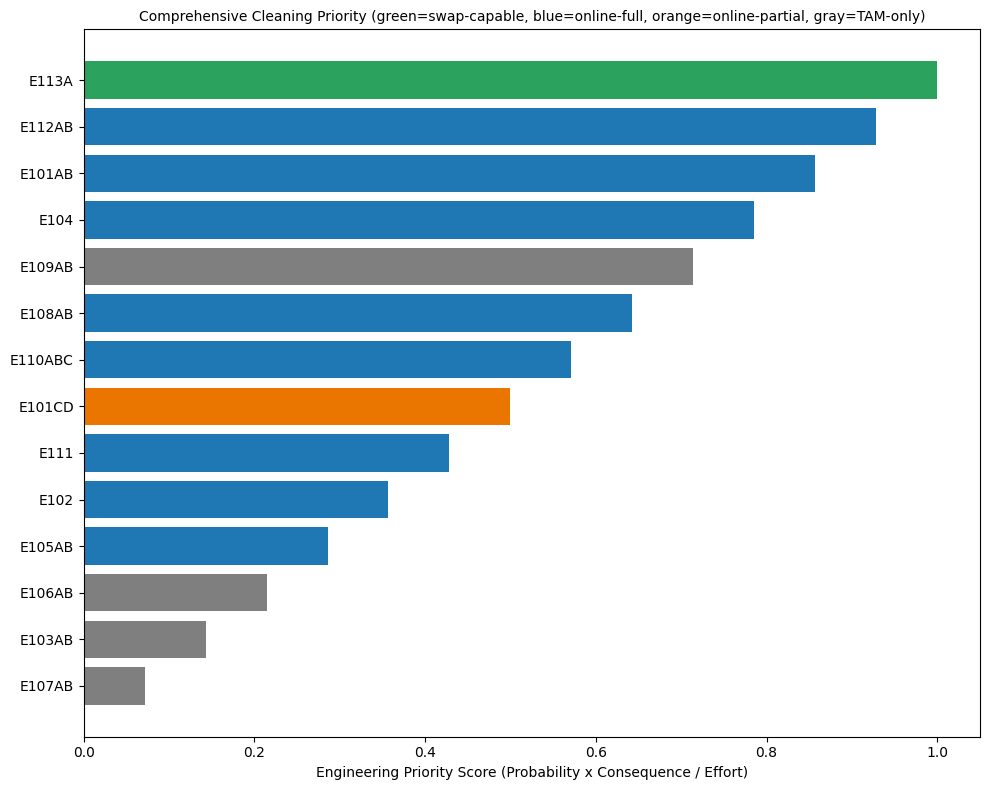

Wrote Engineering_Priority_Score.csv (14, 36)

FINAL RECOMMENDATION -- Comprehensive Engineering Priority
  #1  E113A      (SWAP_CAPABLE              )  Score: 1.000 [SAFETY]
  #2  E112AB     (ONLINE_FULL               )  Score: 0.929 [SAFETY]
  #3  E101AB     (ONLINE_FULL               )  Score: 0.857 [WORSENING]
  #4  E104       (ONLINE_FULL               )  Score: 0.786
  #5  E109AB     (TAM_ONLY                  )  Score: 0.714 [SAFETY]
  #6  E108AB     (ONLINE_FULL               )  Score: 0.643 [WORSENING] [SAFETY]

Can be scheduled online now (SWAP_CAPABLE or ONLINE_CLEAN_DEMONSTRATED):
  E113A, E112AB, E101AB, E104, E108AB, E110ABC, E101CD, E111, E102, E105AB
Must wait for next TAM:
  E109AB, E106AB, E103AB, E107AB


In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
tier_colors = {'SWAP_CAPABLE': '#2ca25f', 'ONLINE_FULL': '#1f77b4', 'ONLINE_PARTIAL': '#EA7600', 'TAM_ONLY': '#7f7f7f'}
colors = [tier_colors[t] for t in eng_ranked['effort_tier']]
ax.barh(eng_ranked['HX'], eng_ranked['engineering_priority_score'], color=colors)
ax.set_xlabel('Engineering Priority Score (Probability x Consequence / Effort)')
ax.set_title('Comprehensive Cleaning Priority (green=swap-capable, blue=online-full, orange=online-partial, gray=TAM-only)',
              fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2d_engineering_priority_score.png'), bbox_inches='tight')
plt.show()

DATA_DIR_ENG = r'C:\Desktop\Bangchak Internship 2026\Data'
eng_ranked.to_csv(DATA_DIR_ENG + r'\Engineering_Priority_Score.csv', index=False)
print('Wrote Engineering_Priority_Score.csv', eng_ranked.shape)

print()
print('=' * 70)
print('FINAL RECOMMENDATION -- Comprehensive Engineering Priority')
print('=' * 70)
for rank, (_, row) in enumerate(eng_ranked.head(6).iterrows(), 1):
    worsen_tag = ' [WORSENING]' if row['worsening'] else ''
    safety_tag = ' [SAFETY]' if row['safety_flag'] else ''
    print(f"  #{rank}  {row['HX']:<10} ({row['effort_tier']:<26s})  "
          f"Score: {row['engineering_priority_score']:.3f}{worsen_tag}{safety_tag}")
print('=' * 70)
print()
print('Can be scheduled online now (SWAP_CAPABLE or ONLINE_CLEAN_DEMONSTRATED):')
print('  ' + ', '.join(eng_ranked.loc[eng_ranked['effort_tier'] != 'TAM_ONLY', 'HX'].tolist()))
print('Must wait for next TAM:')
print('  ' + ', '.join(eng_ranked.loc[eng_ranked['effort_tier'] == 'TAM_ONLY', 'HX'].tolist()))

---
## 5. Summary

Top cleaning recommendations, ranked and reasoned:

In [17]:
print('=' * 70)
print('TOP CLEANING RECOMMENDATIONS -- CIT-Gain Basis')
print('=' * 70)
for rank, (_, row) in enumerate(priority.head(5).iterrows(), 1):
    print(f"  #{rank}  {row['HX']:<10} ({row['group']})  "
          f"Fouling: {row['median_pct_drop_per_30d']:+.1f}%/30d  "
          f"Priority: {row['priority_score']:.3f}  "
          f"Est. CIT gain: +{row['expected_CIT_gain_C']:.1f} degC")
print('=' * 70)

print()
print('=' * 70)
print('TOP CLEANING RECOMMENDATIONS -- Hot-End Coking Risk Basis')
print('=' * 70)
for rank, (_, row) in enumerate(flagged.head(5).iterrows(), 1):
    print(f"  #{rank}  {row['HX']:<10} ({row['group']})  "
          f"Fouling: {row['median_pct_drop_per_30d']:+.1f}%/30d  "
          f"Mean crude-out: {row['mean_cold_out_C']:.0f} degC  "
          f"Coking risk score: {row['coking_risk_score']:.3f}")
print('=' * 70)

print()
print('=' * 70)
print('TOP CLEANING RECOMMENDATIONS -- Residue-Chain Structural Risk Basis')
print('=' * 70)
for rank, (_, row) in enumerate(residue_risk.head(5).iterrows(), 1):
    print(f"  #{rank}  {row['HX']:<10} (chain position {row['chain_position']})  "
          f"Fouling: {row['median_pct_drop_per_30d']:+.1f}%/30d  "
          f"Risk score: {row['residue_chain_risk_score']:.3f}")
print('=' * 70)

if len(inactive):
    print('Currently off/substituted (no live status): ' + ', '.join(inactive['HX'].tolist()))

# Combined action list: three bases merged, ranked within their own basis,
# then interleaved by rank so the overall list reflects 'act on this soon'
# regardless of which method produced the number. A HX can appear more than
# once if it scores highly on more than one basis (e.g. E113A on both
# coking-risk and residue-chain-risk) -- that's a signal, not a dedup bug.
cit_basis = priority[['HX', 'group', 'median_pct_drop_per_30d']].copy()
cit_basis['basis'] = 'CIT_gain'
cit_basis['score'] = priority['priority_score']
cit_basis['detail'] = priority['expected_CIT_gain_C'].map(lambda v: f'+{v:.1f} degC CIT')

risk_basis = flagged[['HX', 'group', 'median_pct_drop_per_30d']].copy()
risk_basis['basis'] = 'Coking_risk'
risk_basis['score'] = flagged['coking_risk_score']
risk_basis['detail'] = flagged['mean_cold_out_C'].map(lambda v: f'{v:.0f} degC crude-out')

residue_basis = residue_risk[['HX', 'median_pct_drop_per_30d']].copy()
residue_basis['group'] = 'CPHT-2'
residue_basis['basis'] = 'Residue_chain_risk'
residue_basis['score'] = residue_risk['residue_chain_risk_score']
residue_basis['detail'] = residue_risk['chain_position'].map(lambda v: f'chain position {v}')

combined_action_list = pd.concat([cit_basis, risk_basis, residue_basis], ignore_index=True)
combined_action_list['rank_within_basis'] = combined_action_list.groupby('basis')['score'].rank(ascending=False)
combined_action_list = combined_action_list.sort_values(['rank_within_basis', 'basis']).reset_index(drop=True)

print()
print('=' * 70)
print('COMBINED ACTION LIST (three bases, interleaved by within-basis rank)')
print('=' * 70)
for _, row in combined_action_list.iterrows():
    print(f"  [{row['basis']:19s}] {row['HX']:<10} ({row['group']})  "
          f"Fouling: {row['median_pct_drop_per_30d']:+.1f}%/30d  {row['detail']}")

DATA_DIR_OUT = r'C:\Desktop\Bangchak Internship 2026\Data'
ranking.to_csv(DATA_DIR_OUT + r'\Cleaning_Priority_Ranking.csv', index=False)
print('Wrote Cleaning_Priority_Ranking.csv', ranking.shape)
# combined_action_list is printed above for the interleaved 3-basis view but is not
# exported -- no downstream script/notebook reads a Cleaning_Combined_Action_List.csv
# (confirmed by repo-wide grep, 2026-07-12 pipeline audit); Engineering_Priority_Score.csv
# (written later in this notebook) is the ranking file actually consumed downstream.

TOP CLEANING RECOMMENDATIONS -- CIT-Gain Basis
  #1  E102       (CPHT-1)  Fouling: -0.2%/30d  Priority: 0.042  Est. CIT gain: +9.2 degC
  #2  E101CD     (CPHT-1)  Fouling: -0.5%/30d  Priority: 0.023  Est. CIT gain: +5.6 degC
  #3  E101AB     (CPHT-1)  Fouling: -0.5%/30d  Priority: 0.018  Est. CIT gain: +4.4 degC
  #4  E106AB     (CPHT-2)  Fouling: -1.1%/30d  Priority: 0.008  Est. CIT gain: +1.4 degC
  #5  E113A      (CPHT-2)  Fouling: -5.3%/30d  Priority: 0.008  Est. CIT gain: +9.2 degC

TOP CLEANING RECOMMENDATIONS -- Hot-End Coking Risk Basis
  #1  E107AB     (CPHT-2)  Fouling: -6.5%/30d  Mean crude-out: 168 degC  Coking risk score: 0.490
  #2  E109AB     (CPHT-2)  Fouling: -3.4%/30d  Mean crude-out: 222 degC  Coking risk score: 0.440
  #3  E111       (CPHT-2)  Fouling: -1.1%/30d  Mean crude-out: 169 degC  Coking risk score: 0.082

TOP CLEANING RECOMMENDATIONS -- Residue-Chain Structural Risk Basis
  #1  E113A      (chain position 1)  Fouling: -5.3%/30d  Risk score: 1.000
  #2  E112A

---
## 6. Limitations

- **CPHT-1 gain estimates (E102, E101AB, E101CD) are the least trustworthy
  numbers in this table.** `E102`'s +11.3 degC estimate is implausibly large
  for one HX given CPHT-1's entire job is raising crude from ~37 degC to
  the desalter feed temperature — a single-variable regression against CIT
  can't separate "this HX's own fouling" from "this HX's Q moves with overall
  plant health/season, which also moves CIT." CPHT-1's true effect on CIT is
  indirect (via desalter outlet temperature, not measured directly here), so
  treat these three rows as **directional (still plausibly top-4), not
  quantitatively reliable** until a desalter-outlet-mediated model replaces
  this simple regression. CPHT-2 rows sit on a literal series chain to CIT
  and are comparatively more trustworthy.
- `Q_shortfall` is derived from `2b`'s campaign baseline/current snapshot, not
  a live regression forecast — it's a point-in-time estimate, re-run
  periodically as new data comes in rather than treated as a fixed number.
- Terminal-position HX (E113A, E112C, E111, E109AB, E112AB) now get a coking-risk
  score (section 1.5-1.6) and, where they sit in the residue chain, a residue-chain
  risk score (section 1.7-1.8) instead of a CIT-degC number -- still not directly
  comparable to the CIT-gain figures, but no longer dropped from the ranking.
- The crude-property vs fouling-rate correlation for the residue chain (section 1.7)
  is exploratory only -- 3-6 online-clean runs per HX is too few for statistical
  confidence (all p > 0.15). Re-run once more cleaning cycles accumulate; until then,
  the residue-chain risk score uses chain position + measured fouling rate only, not
  a fitted crude-quality effect.
- No cleaning cost/downtime data is incorporated — this ranks *benefit*, not
  benefit-per-effort. Combine with a maintenance cost/duration estimate before
  scheduling.
- This consolidates and re-grounds the equivalent analysis in
  `09_cit_ranking_baseline.ipynb` (sections 5-7, 11) on the corrected
  `Operating_State.csv` from `2a` — that notebook's ML CIT-prediction sections
  (8-10) are a separate, larger deliverable (full CIT forecasting model) and
  are out of scope here.